# Challenge 5 — DBSCAN Clustering

## Public Health & Epidemiology

This notebook implements DBSCAN (Density-Based Spatial Clustering of Applications with Noise) on the BRFSS dataset.

Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand. Instead, it identifies dense regions in the feature space and explicitly labels sparse observations as noise or outliers.

This approach is particularly useful for:
- detecting irregular cluster shapes,
- identifying anomalous health profiles,
- and analyzing continuous population structures.

The analysis includes:
- k-nearest-neighbor distance analysis,
- hyperparameter tuning,
- cluster evaluation metrics,
- noise fraction analysis,
- and PCA-based visualizations.

In [1]:
# =========================================================
# DBSCAN CLUSTERING
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading

DBSCAN is highly sensitive to high-dimensional feature spaces because distance relationships become less informative as dimensionality increases.

To improve density estimation and clustering stability, DBSCAN will be applied to the PCA-reduced dataset retaining 90% of the total variance.

In [2]:
# =========================
# Load PCA dataset
# =========================

X_pca = np.load("../results/X_pca.npy")

print("PCA dataset shape:", X_pca.shape)

PCA dataset shape: (29999, 20)


# Hyperparameter Selection — k-NN Distance Plot

DBSCAN requires selecting:
- `eps`: neighborhood radius
- `min_samples`: minimum number of neighbors required to form a dense region

To estimate a suitable `eps` value, a k-nearest-neighbor distance plot is used.

The optimal `eps` is typically located near the point where the curve begins to increase sharply (the “elbow”).

In [3]:
# =========================
# Initial DBSCAN parameters
# =========================

min_samples = 10

In [4]:
# =========================
# k-NN Distance Computation
# =========================

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

# Sort distances
distances = np.sort(distances[:, -1])

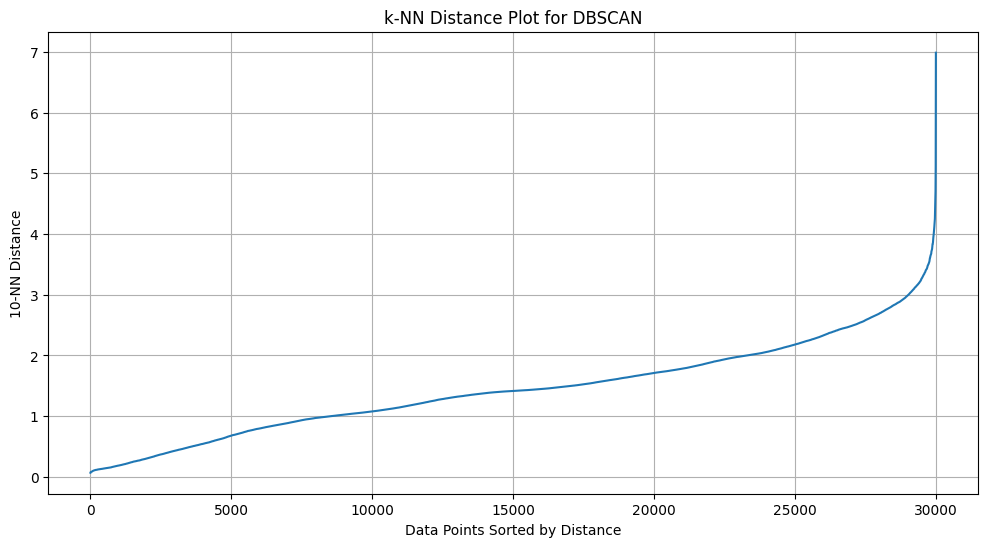

In [5]:
# =========================
# k-NN Distance Plot
# =========================

plt.figure(figsize=(12, 6))

plt.plot(distances)

plt.xlabel("Data Points Sorted by Distance")
plt.ylabel(f"{min_samples}-NN Distance")

plt.title("k-NN Distance Plot for DBSCAN")

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/knn_distance_plot.png', dpi=300, bbox_inches='tight')

plt.show()

# Hyperparameter Sensitivity Analysis

DBSCAN is highly sensitive to the choice of `eps` and `min_samples`.

To evaluate clustering stability and density structure, multiple `eps` values are tested while keeping `min_samples` fixed.

For each configuration, the following are analyzed:
- number of clusters discovered,
- proportion of noise points,
- clustering evaluation metrics.

In [6]:
# =========================
# DBSCAN Hyperparameter Sweep
# =========================

eps_values = [2.5, 2.7, 2.9, 3.1]

results = []